In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
## creating database connection 
conn = sqlite3.connect('vendorinventory.db')

In [13]:
#checking the tables present in our db
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",conn)
tables

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,sales
5,vendor_invoice
6,fvender_sale_summary
7,vender_sale_summary


In [16]:
# loading vender_sale_summary table into df

df = pd.read_sql("SELECT * FROM vender_sale_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSaleDollar,TotalSalePrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRation
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [17]:
df.shape

(10692, 18)

## Exploratory Data Analysis
* Previously, we examined multiple tables to identify the optimal columns for our final dataset.
* Now, we will conduct a comprehensive analysis of this dataset to uncover patterns, examine column distributions, and gain a clearer understanding of the data. and try to answer the business problems.

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Actualprice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollar,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSaleDollar,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalePrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


In [20]:
round(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10651.0,18754.0,2.0,3951.0,7153.0,9552.0,201359.0
Brand,10692.0,18039.0,12662.0,58.0,5794.0,18762.0,25514.0,90631.0
PurchasePrice,10692.0,24.0,109.0,0.0,7.0,10.0,19.0,5682.0
Actualprice,10692.0,36.0,148.0,0.0,11.0,16.0,29.0,7500.0
Volume,10692.0,847.0,664.0,50.0,750.0,750.0,750.0,20000.0
TotalPurchaseQuantity,10692.0,3141.0,11095.0,1.0,36.0,262.0,1976.0,337660.0
TotalPurchaseDollar,10692.0,30107.0,123068.0,1.0,453.0,3655.0,20738.0,3811252.0
TotalSalesQuantity,10692.0,3077.0,10953.0,0.0,33.0,261.0,1929.0,334939.0
TotalSaleDollar,10692.0,42239.0,167655.0,0.0,729.0,5298.0,28397.0,5101920.0
TotalSalePrice,10692.0,18794.0,44953.0,0.0,290.0,2858.0,16060.0,672819.0


In [21]:
# taking all the numerical columns 

numerical_col = df.select_dtypes(include=np.number).columns
numerical_col

Index(['VendorNumber', 'Brand', 'PurchasePrice', 'Actualprice', 'Volume',
       'TotalPurchaseQuantity', 'TotalPurchaseDollar', 'TotalSalesQuantity',
       'TotalSaleDollar', 'TotalSalePrice', 'TotalExciseTax', 'FreightCost',
       'GrossProfit', 'ProfitMargin', 'StockTurnover',
       'SalesToPurchaseRation'],
      dtype='object')

In [22]:
# distribution plot of all numerical columns 

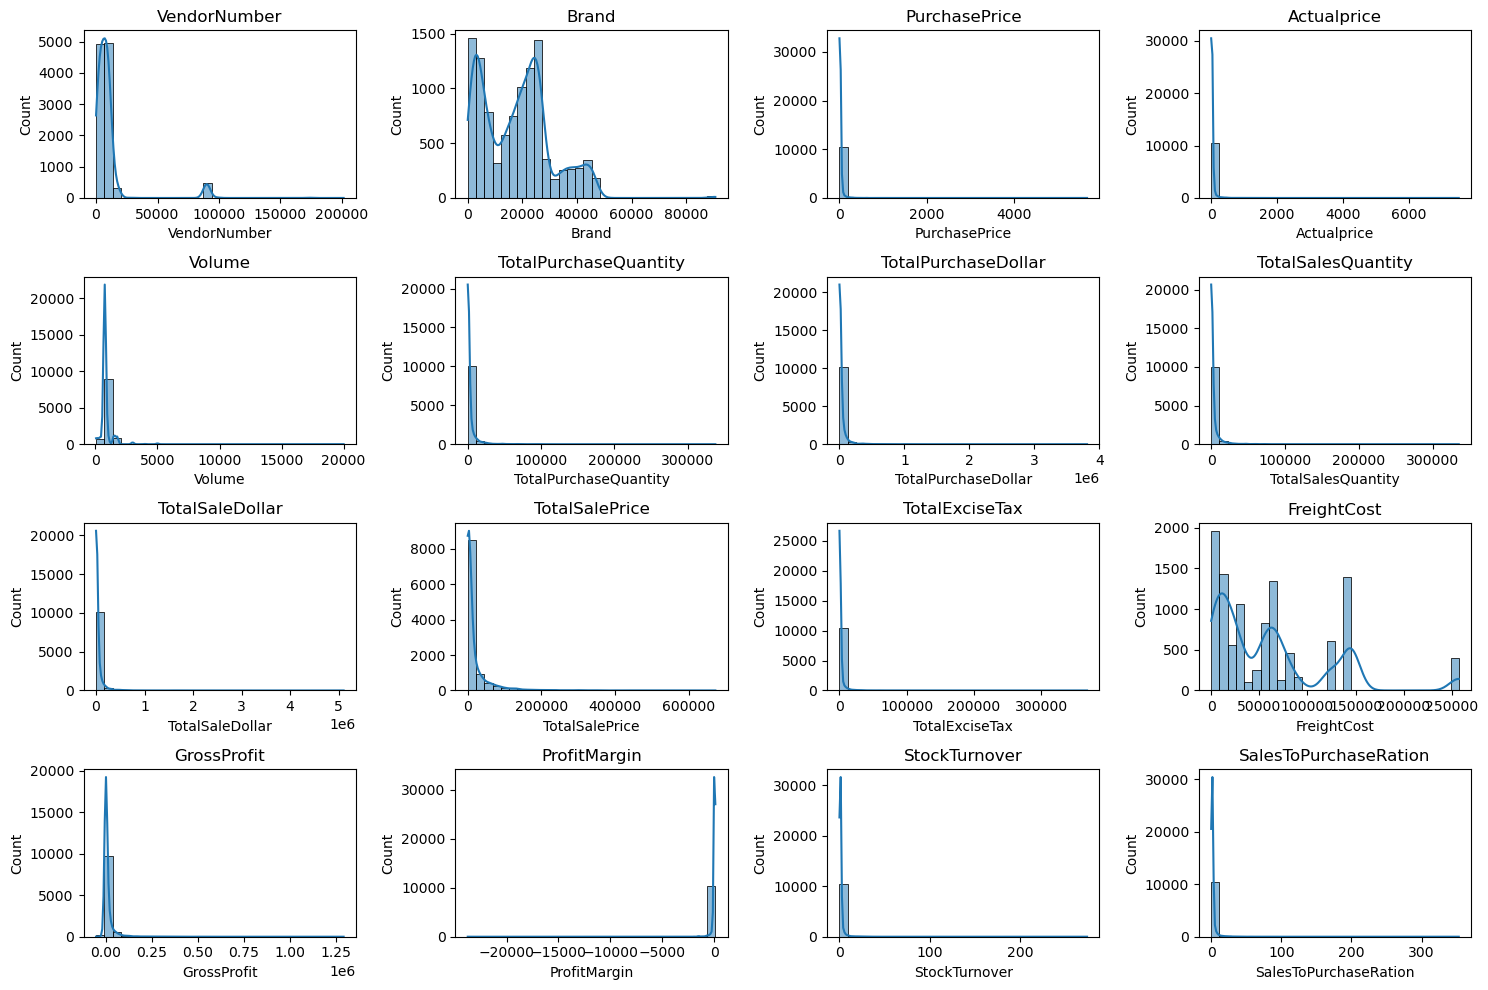

In [24]:
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_col):
    plt.subplot(4,4, i+1) #adjust grid layout as needed
    sns.histplot(df[col],kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

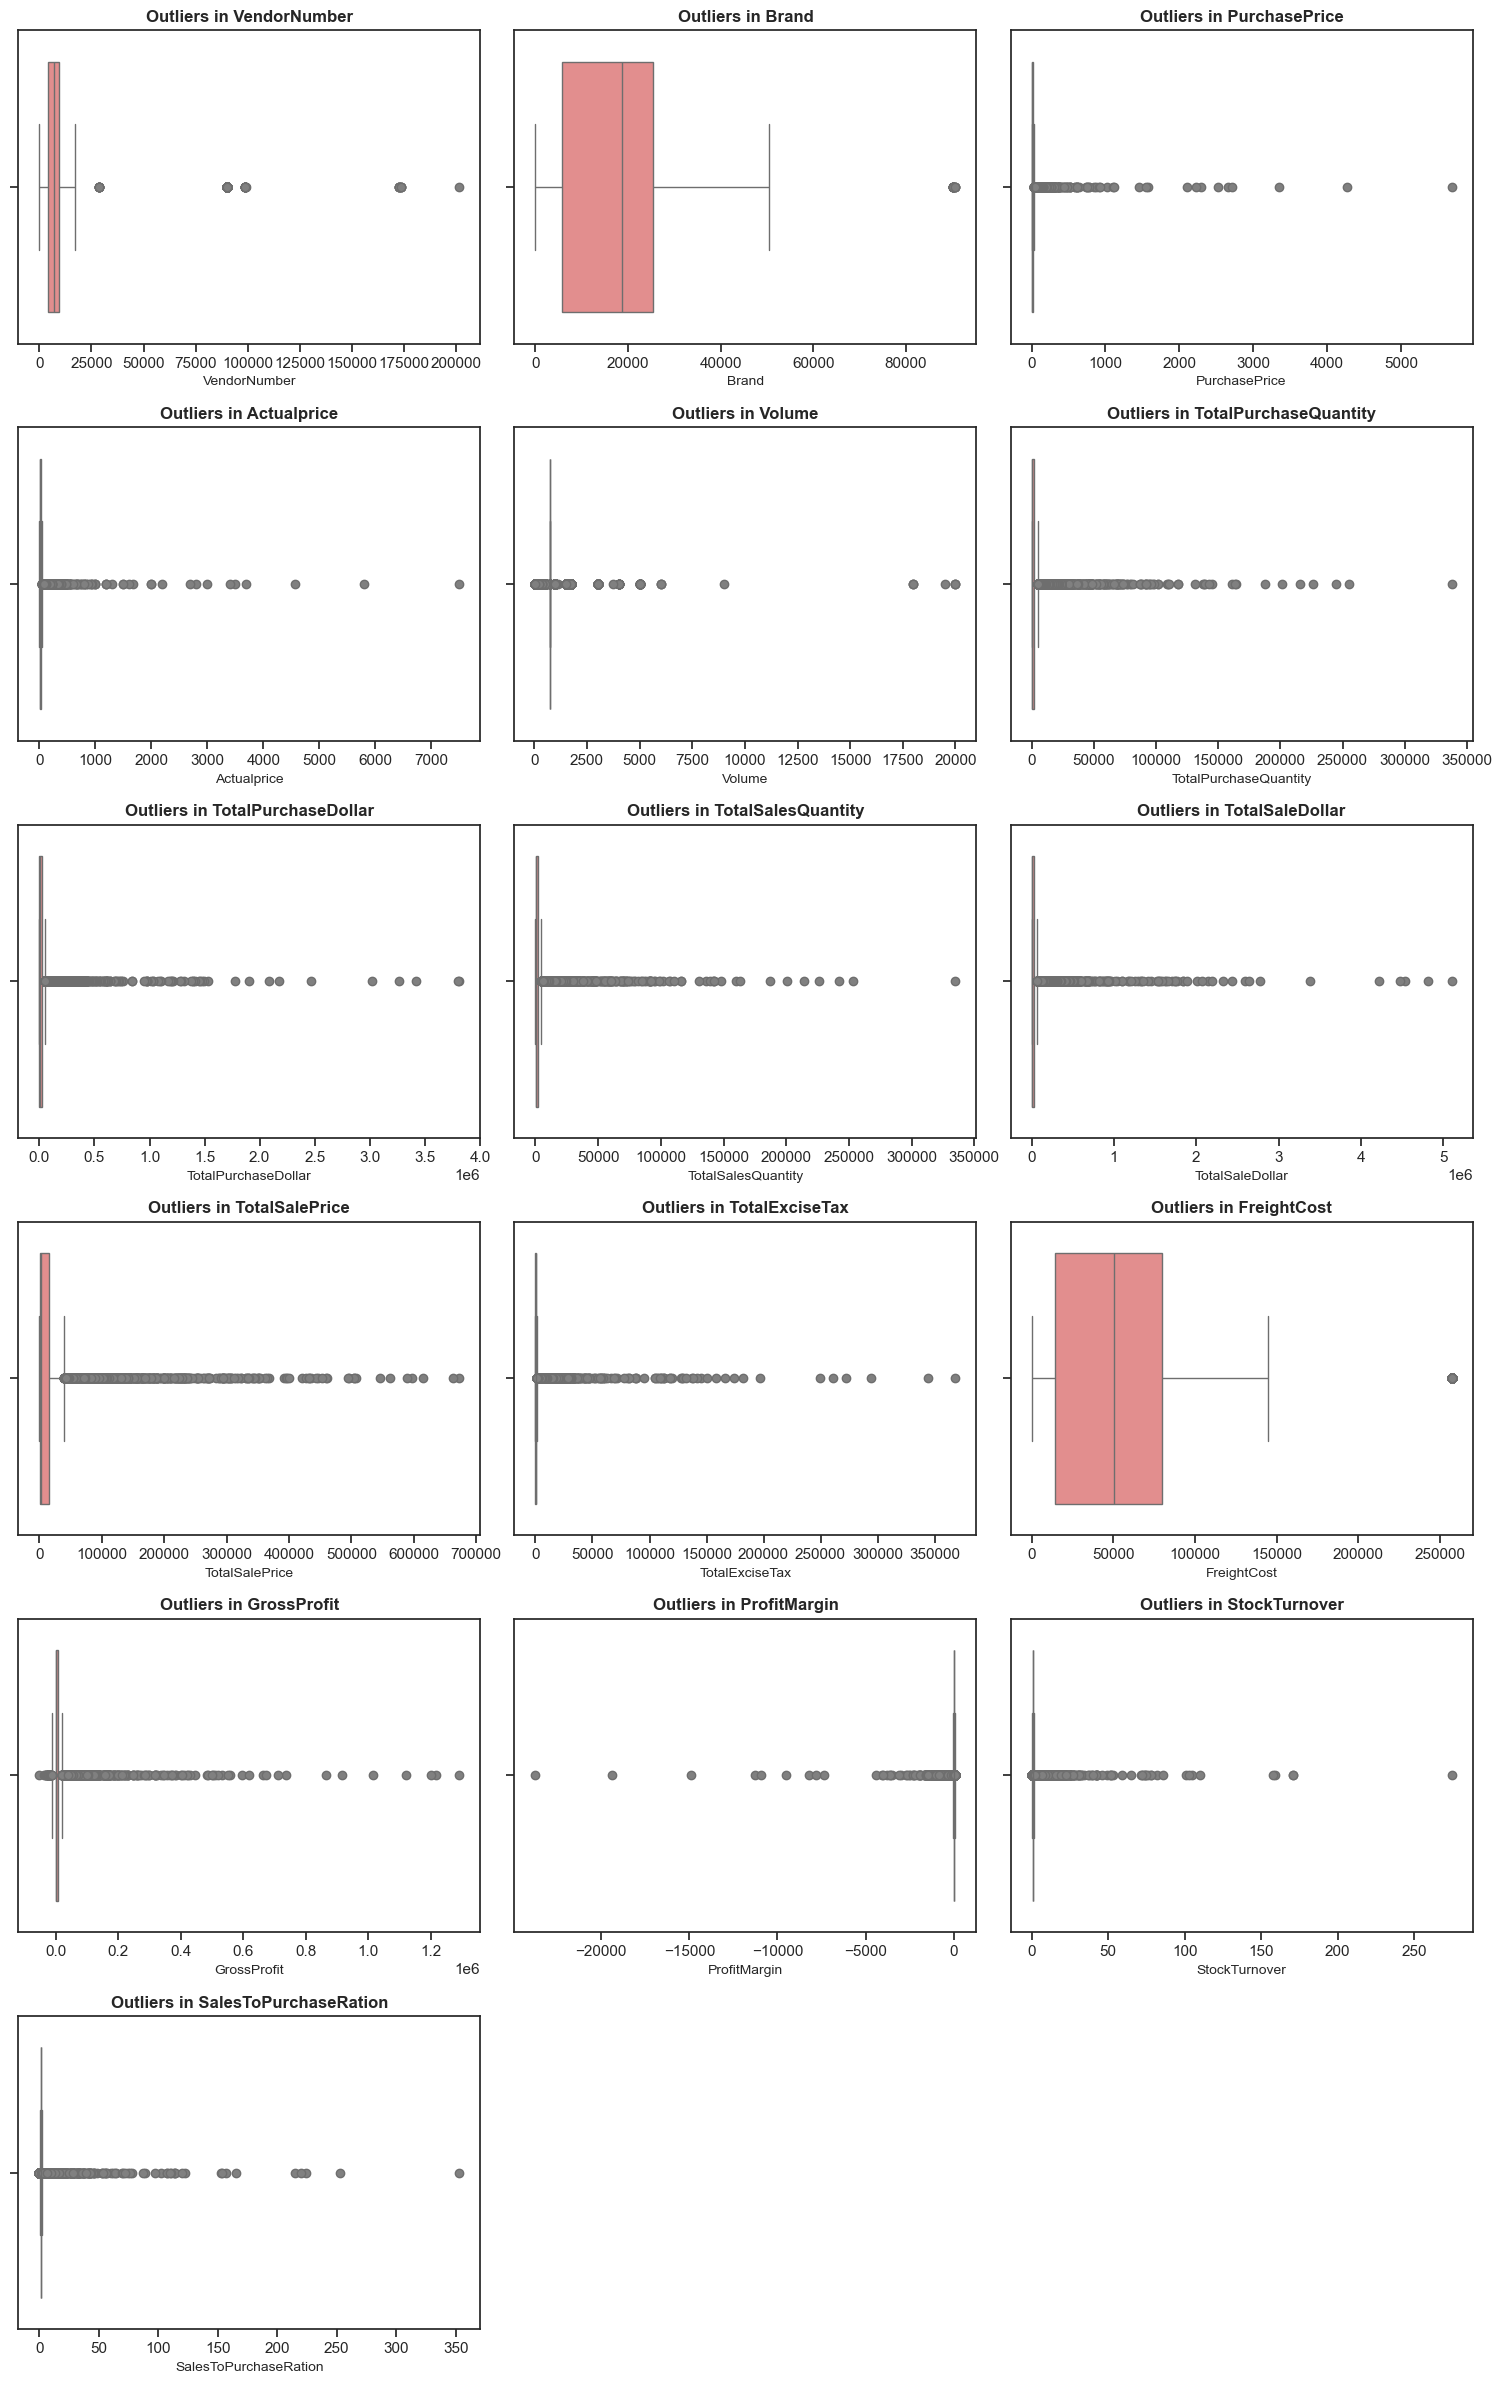

In [26]:
# Maximum data is seems to be skewed data there must be some outliers will see using the box plot

# 1. Define the grid structure dynamically based on your column count
num_cols = len(numerical_col)
grid_cols = 3  # Display 3 plots per row
grid_rows = int(np.ceil(num_cols / grid_cols))

# 2. Initialize the matplotlib figure layout
plt.figure(figsize=(5 * grid_cols, 4 * grid_rows))
sns.set_theme(style="ticks")  # Clean background suited for boxplots

# 3. Loop through your list and map each column to a subplot box
for i, col in enumerate(numerical_col):
    plt.subplot(grid_rows, grid_cols, i + 1)
    
    # Horizontal boxplot to easily read large transaction values
    sns.boxplot(x=df[col], color="lightcoral", flierprops={"markerfacecolor": "grey", "marker": "o"})
    
    # Titles and formatting
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)

# 4. Prevent text overlap between rows and columns
plt.tight_layout()

# 5. Render the chart
plt.show()

## Summary Statistics

### Negative and Zero Values:
* Gross profit: minimum value is -52002.78 which indicates that the some products may selling at a lower than the purchase price or may be they are giving some discounts but it is showing big loss.
* Profit margins: have seen a minimum infinity which indicates there is a problem with that column we need to fix it later
* TotalSalesQuantity, TotalSaleDollar, TotalSalePrice, TotalExciseTax is showing zero at minimum value which means there are some products which never sold.

### Outliers Indicated by High SD (Standard Deviation):
* after round off the Max value of PurchasePrice is 5682.0 and Actualprice is 7500 are significantly higher than the avg prices (24,36) which indicates that there is some premium products.
* Freight Cost: Huge Variation from (0.09 to 257032.0) it happens primarily because of bulk shipments.
* Stock Turnover: Ranges from (0 to 274) indicates some products sell very fast while others are still in stock value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fullfiled from older stock

In [101]:
# to eliminate the values less than 0 we will create new dataframe

df = pd.read_sql_query("""SELECT * 
    FROM vender_sale_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0
    
    """,conn)

In [102]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSaleDollar,TotalSalePrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRation
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [120]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8564.0,10107.074965,17635.714818,2.000000,3664.000000,7153.000000,9552.000000,2.013590e+05
Brand,8564.0,17614.670131,12946.130933,58.000000,5375.750000,17606.000000,24935.250000,9.063100e+04
PurchasePrice,8564.0,21.780897,81.189624,0.360000,6.660000,10.060000,17.850000,3.352930e+03
Actualprice,8564.0,32.297467,112.420744,0.490000,9.990000,14.990000,25.990000,4.559990e+03
Volume,8564.0,864.332263,724.240079,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,8564.0,3772.008991,12276.960631,1.000000,42.000000,431.000000,2666.750000,3.376600e+05
TotalPurchaseDollar,8564.0,35887.253324,136722.999153,0.710000,546.187500,5018.400000,26610.177500,3.811252e+06
TotalSalesQuantity,8564.0,3748.983419,12125.696083,1.000000,62.000000,490.500000,2675.000000,3.349390e+05
TotalSaleDollar,8564.0,51542.278077,186071.489729,1.980000,1355.580000,8483.780000,40622.112500,5.101920e+06
TotalSalePrice,8564.0,22759.270732,49305.274018,0.990000,584.790000,4549.755000,22595.252500,6.728193e+05


In [121]:
df.shape

(8564, 18)

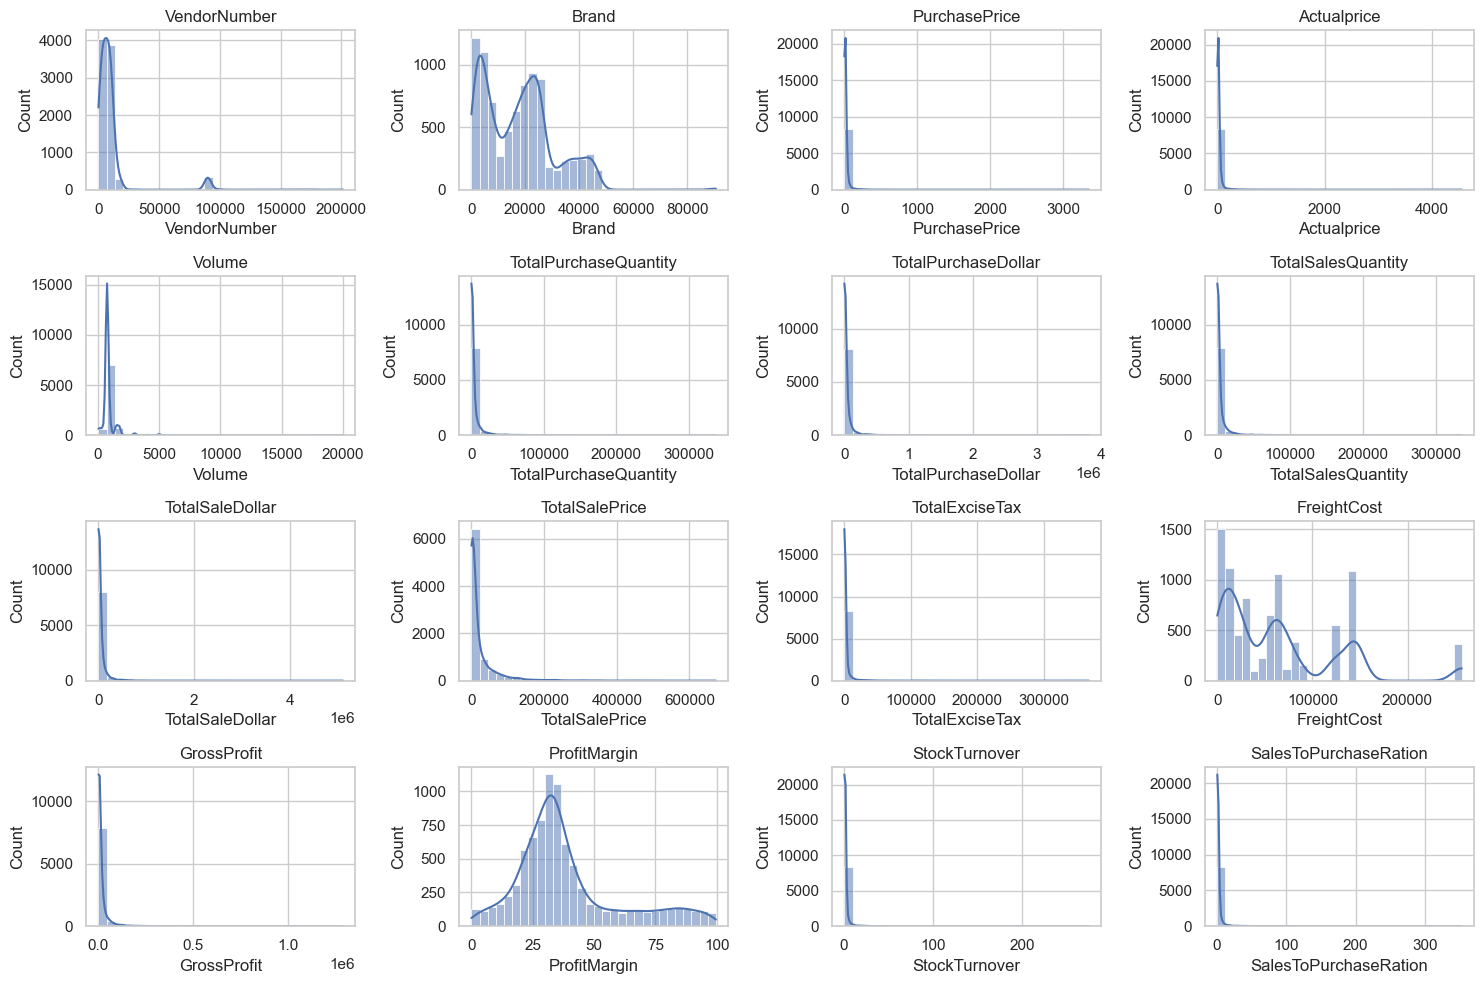

In [122]:
# Distribution plots for numerical columns 

numerical_col = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_col): 
    plt.subplot(4,4, i+1)  #adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


In [103]:
# lets see the categorical columns 

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Print the results clearly
print("--- Categorical Columns List ---")
print(categorical_cols)

--- Categorical Columns List ---
['VendorName', 'Description']


In [104]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSaleDollar,TotalSalePrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRation
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [105]:
top_10_vendors_data = (
    df.groupby('VendorName')['Description']
    .nunique()
    .reset_index(name='UniqueProductCount')
    .sort_values(by='UniqueProductCount', ascending=False)
    .head(10)
)

# Printing the structured table to verify the numbers
print(top_10_vendors_data)

                     VendorName  UniqueProductCount
57        MARTIGNETTI COMPANIES                1046
53               M S WALKER INC                 637
106  ULTRA BEVERAGE COMPANY LLP                 596
67               PERFECTA WINES                 568
30           E & J GALLO WINERY                 350
20     CONSTELLATION BRANDS INC                 324
70        PINE STATE TRADING CO                 274
46      JIM BEAM BRANDS COMPANY                 256
88   SOUTHERN WINE & SPIRITS NE                 254
25     DIAGEO NORTH AMERICA INC                 228


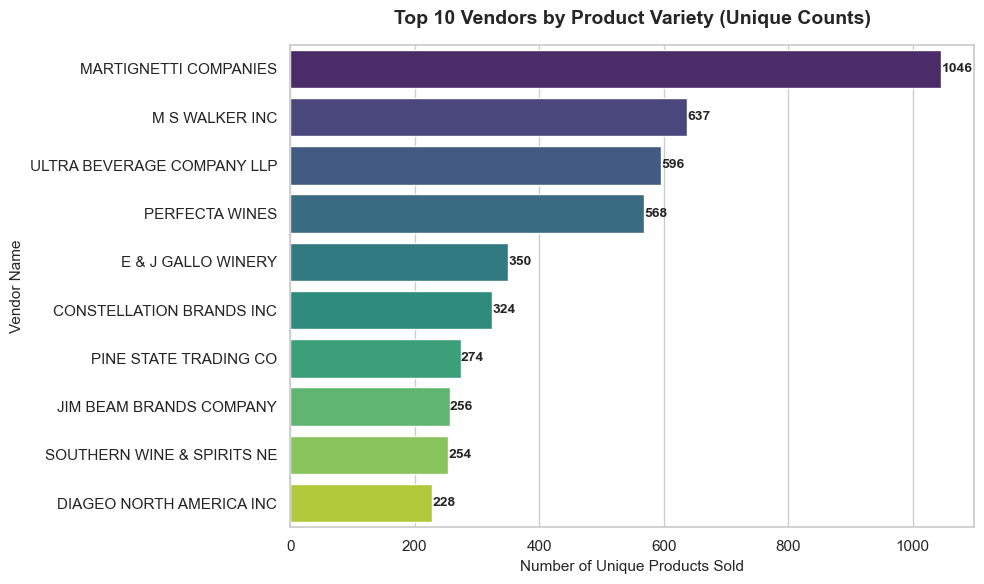

In [106]:
#lets visualize this record 

# 1. Set the background style and size of the chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")  # Adds a clean background grid for easy reading

# 2. Create a horizontal bar plot
# We map UniqueProductCount to X (length of bars) and VendorName to Y
sns.barplot(
    x='UniqueProductCount', 
    y='VendorName', 
    data=top_10_vendors_data, 
    palette='viridis'  # A smooth blue-to-green gradient color palette
)

# 3. Add exact numeric labels on top of each bar so you don't have to guess the value
for index, value in enumerate(top_10_vendors_data['UniqueProductCount']):
    plt.text(value + 0.5, index, f'{value}', va='center', fontsize=10, fontweight='bold')

# 4. Add titles and axis labels for clear scannability
plt.title('Top 10 Vendors by Product Variety (Unique Counts)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Unique Products Sold', fontsize=11)
plt.ylabel('Vendor Name', fontsize=11)

# 5. Automatically adjust spacing so nothing gets cut off
plt.tight_layout()

# 6. Display the plot
plt.show()

In [107]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'Actualprice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollar',
       'TotalSalesQuantity', 'TotalSaleDollar', 'TotalSalePrice',
       'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin',
       'StockTurnover', 'SalesToPurchaseRation'],
      dtype='object')

In [108]:
top_10_products = (df.groupby('Description').agg({
    'TotalSaleDollar' : 'sum', 
    'GrossProfit' : 'sum'
}).sort_values(by='TotalSaleDollar', ascending=False).head(10)

                  )

top_10_products
   

,TotalSaleDollar,GrossProfit
Description,,
Jack Daniels No 7 Black,7964746.76,2139961.60
Tito's Handmade Vodka,7399657.58,1781028.26
Grey Goose Vodka,7209608.06,1946003.09
Capt Morgan Spiced Rum,6356320.62,1733386.12
Absolut 80 Proof,6244752.03,1599051.94
Jameson Irish Whiskey,5715759.69,1406395.29
Ketel One Vodka,5070083.56,1396122.04
Baileys Irish Cream,4150122.07,1219790.65
Kahlua,3604858.66,888765.01


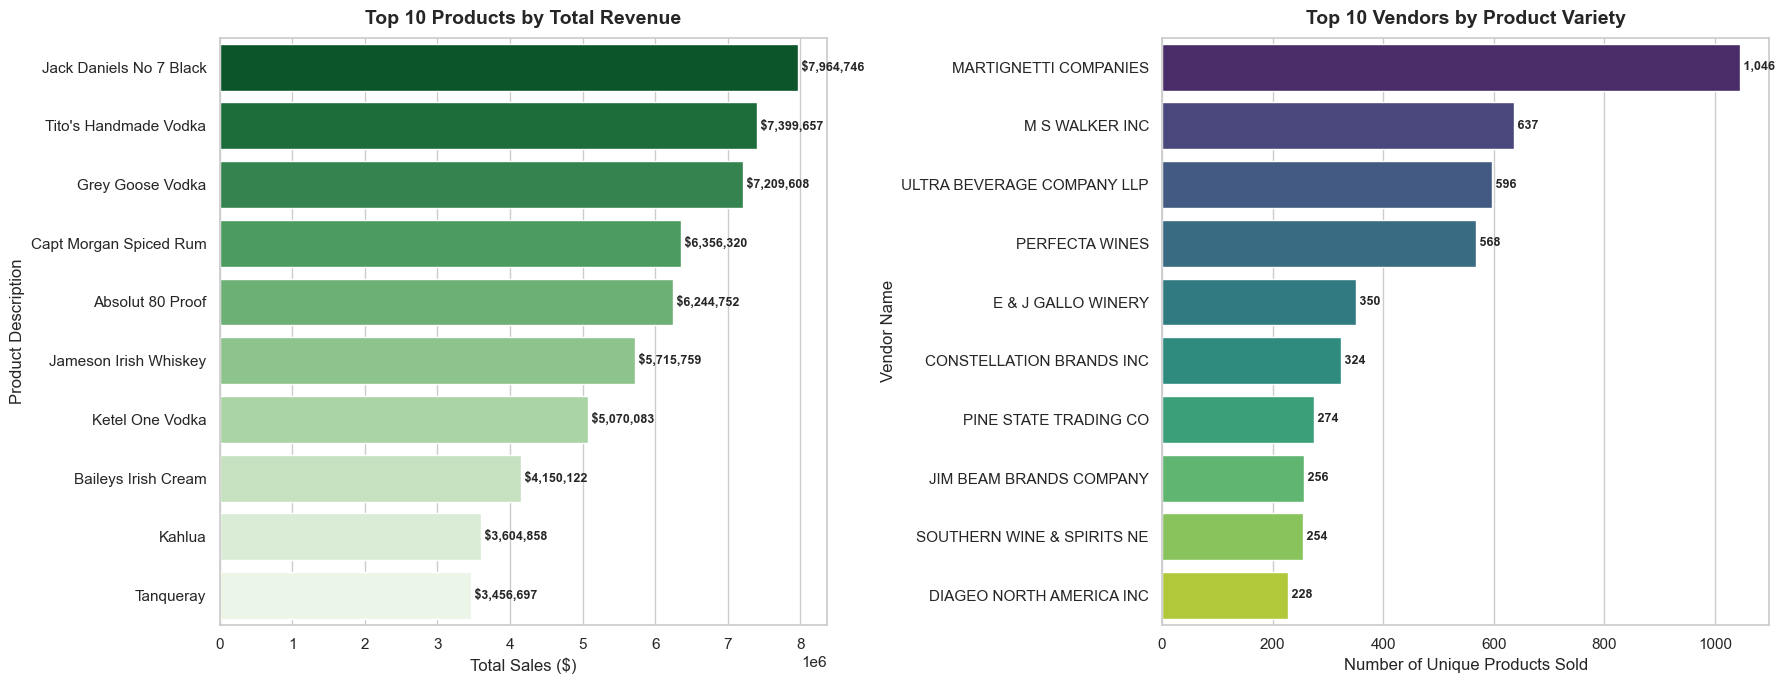

In [109]:
#lets plot both graphs side by side top10 vendors and pproducts

# 1. Initialize a side-by-side canvas (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# --- PLOT 1: Top 10 Products by Revenue (Left Side) ---
sns.barplot(
    x=top_10_products['TotalSaleDollar'], 
    y=top_10_products.index,  # Uses 'Description' from the index
    ax=axes[0], 
    palette='Greens_r'  # Clean green gradient for revenue
)
axes[0].set_title('Top 10 Products by Total Revenue', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Product Description')

# Add currency formatting labels next to the product bars
for index, value in enumerate(top_10_products['TotalSaleDollar']):
    axes[0].text(value, index, f' ${int(value):,}', va='center', fontsize=9, fontweight='bold')


# --- PLOT 2: Top 10 Vendors by Product Variety (Right Side) ---
sns.barplot(
    x='UniqueProductCount', 
    y='VendorName', 
    data=top_10_vendors_data, 
    ax=axes[1], 
    palette='viridis'  # Keeps your previous professional color choices
)
axes[1].set_title('Top 10 Vendors by Product Variety', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Number of Unique Products Sold')
axes[1].set_ylabel('Vendor Name')

# Add numeric count labels next to the vendor bars
for index, value in enumerate(top_10_vendors_data['UniqueProductCount']):
    axes[1].text(value, index, f' {int(value):,}', va='center', fontsize=9, fontweight='bold')


# 2. Fix the spacing so text fields do not squash together
plt.tight_layout()

# 3. Present the combined visual plots
plt.show()

In [110]:
# now we will see the correlation between numerical columns so for that we will use heatmap

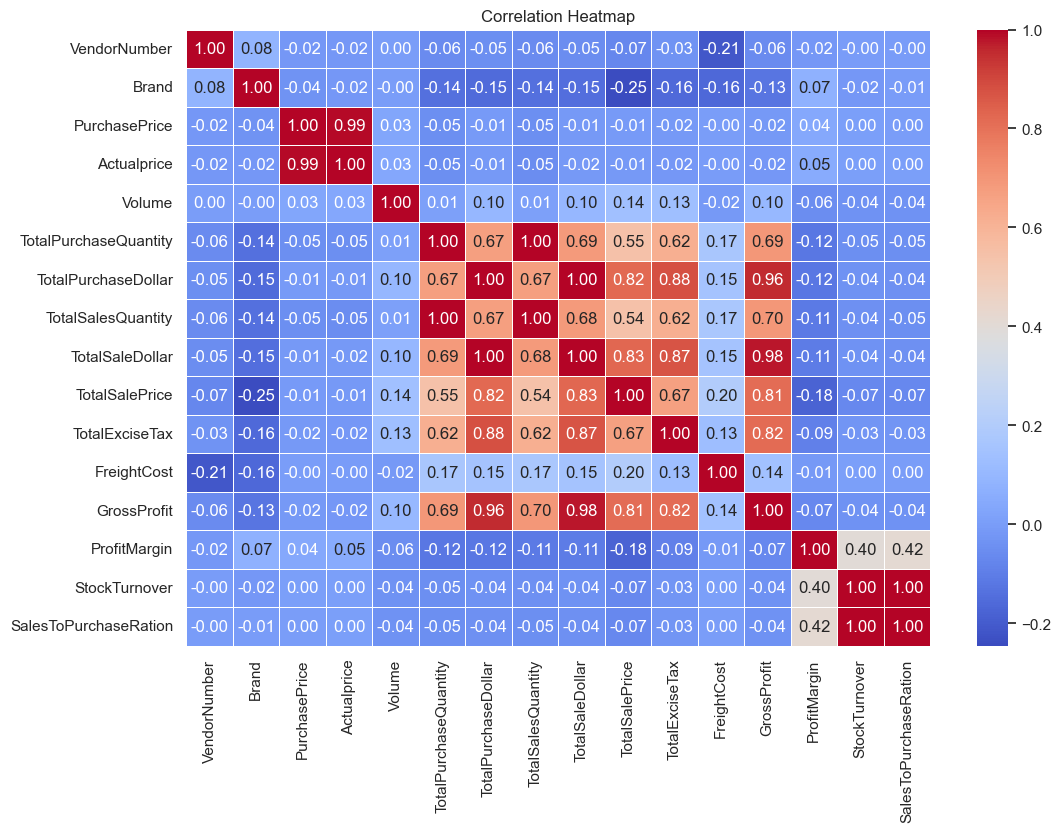

In [111]:
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_col].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#### There is a perfect 1.00 score between Total Purchases and Total Sales.
* This is great news for the business. It shows that almost every item our team buys from vendors gets sold to customers quickly. The warehouse is not filling up with old, unwanted stock.

#### Gross Profit has an extremely high score (0.98) with Total Sales Dollars.
* profit depends completely on selling a high number of products. Trying to change or increase the price of a single product will not help much.

#### Profit Margin has a small minus score (-0.11) with Total Sales.
* This is a small warning sign. It shows that when we sell huge amounts of items, our profit percentage drops a little bit. This happens because of giving big discounts to customers just to clear out the stock quickly.

#### StockTurnover and SalesToPurchaseRatio have a perfect 1.00 score together.
* These two columns are showing the exact same thing on the chart. To keep our data clean and simple for the final dashboard, we do not need both. We can safely delete one of them.



## Data Analysis Solving Business Questions

##### Identify Brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins.

In [112]:
brand_performance = df.groupby(['Description']).agg({
    'TotalSaleDollar' : 'sum', 
    'ProfitMargin' : 'mean'
}).reset_index()

brand_performance

,Description,TotalSaleDollar,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [113]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'Actualprice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollar',
       'TotalSalesQuantity', 'TotalSaleDollar', 'TotalSalePrice',
       'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin',
       'StockTurnover', 'SalesToPurchaseRation'],
      dtype='object')

In [114]:
lower_sale_threshold = brand_performance['TotalSaleDollar'].quantile(0.15)
higher_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [115]:
lower_sale_threshold

np.float64(560.299)

In [116]:
higher_margin_threshold

np.float64(64.97017552750113)

In [117]:
## filter brands with low sales but high profit margins 

target_brands = brand_performance[
    (brand_performance['TotalSaleDollar'] <= lower_sale_threshold) & 
    (brand_performance['ProfitMargin'] >= higher_margin_threshold)
]

print("Brands with low Sales but High Profit Margins:")
display(target_table.sort_values('TotalSaleDollar'))

Brands with low Sales but High Profit Margins:


,Description,TotalSaleDollar,ProfitMargin
7777,Santa Rita Organic Svgn Bl,9.99,66.466466
2896,Debauchery Pnt Nr,11.58,65.975820
2537,Concannon Glen Ellen Wh Zin,15.95,83.448276
2677,Crown Royal Apple,27.86,89.806174
7818,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
8939,Tommasi Poggio Tufo Cab Svgn,269.73,74.789604
9229,Vigne A Porrona Rosso,272.79,96.825397
5736,Mad Dogs & Englishmen Jumil,279.80,97.666190
3980,Gifft Chardonnay,279.80,94.245890


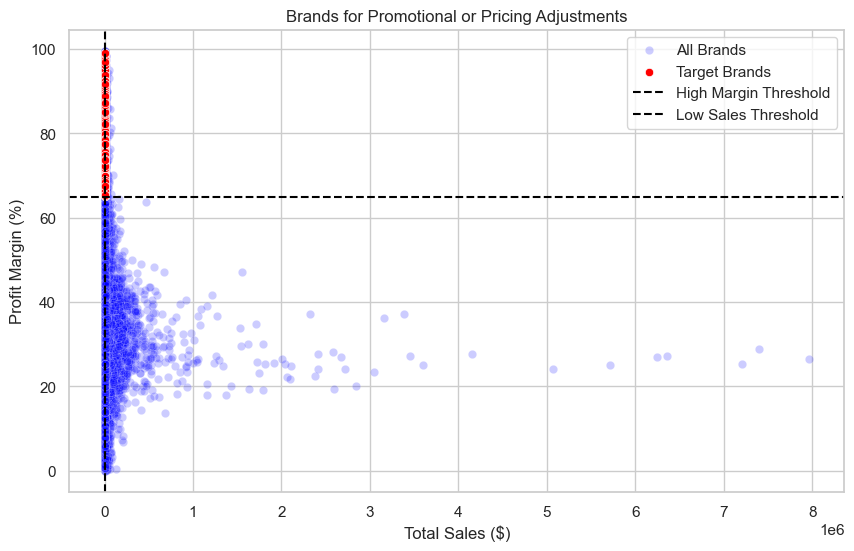

In [118]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSaleDollar', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSaleDollar', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(higher_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(lower_sale_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [123]:
# there are some outliers thats why we can not see the plot clearly 

brand_performance = brand_performance[brand_performance['TotalSaleDollar']<10000] #just for better visualization

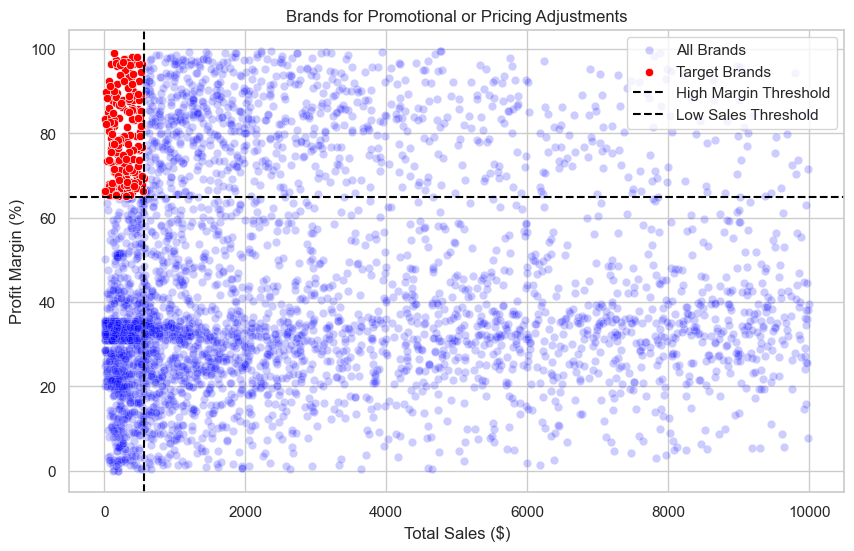

In [124]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSaleDollar', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSaleDollar', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(higher_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(lower_sale_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

##### Which vendors and brands demonstrate the highest sales performance?

In [128]:
#top vendors and brands by sales 
top_vendors = df.groupby('VendorName')['TotalSaleDollar'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSaleDollar'].sum().nlargest(10)

In [129]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSaleDollar, dtype: float64

In [130]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSaleDollar, dtype: float64

In [154]:
## to see the numbers properly in k or M like we will create one function

def format_dollars(value):
    if value >= 1000000:
        return f"{value / 1000000:.2f}M"  # 🌟 Bracket aur quote ki jagah theek ki
    elif value >= 1000:
        return f"{value / 1000:.2f}K"  # 🌟 Bracket aur quote ki jagah theek ki
    else:
        return str(value)


In [131]:
# now we will see with the Top Brand-Vendor Combination to  identifying exactly which 
# specific brands, supplied by which vendors, generate the highest sales

In [157]:
top_vendors.apply(format_dollars)

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSaleDollar, dtype: object

In [158]:
top_brands.apply(format_dollars)

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSaleDollar, dtype: object

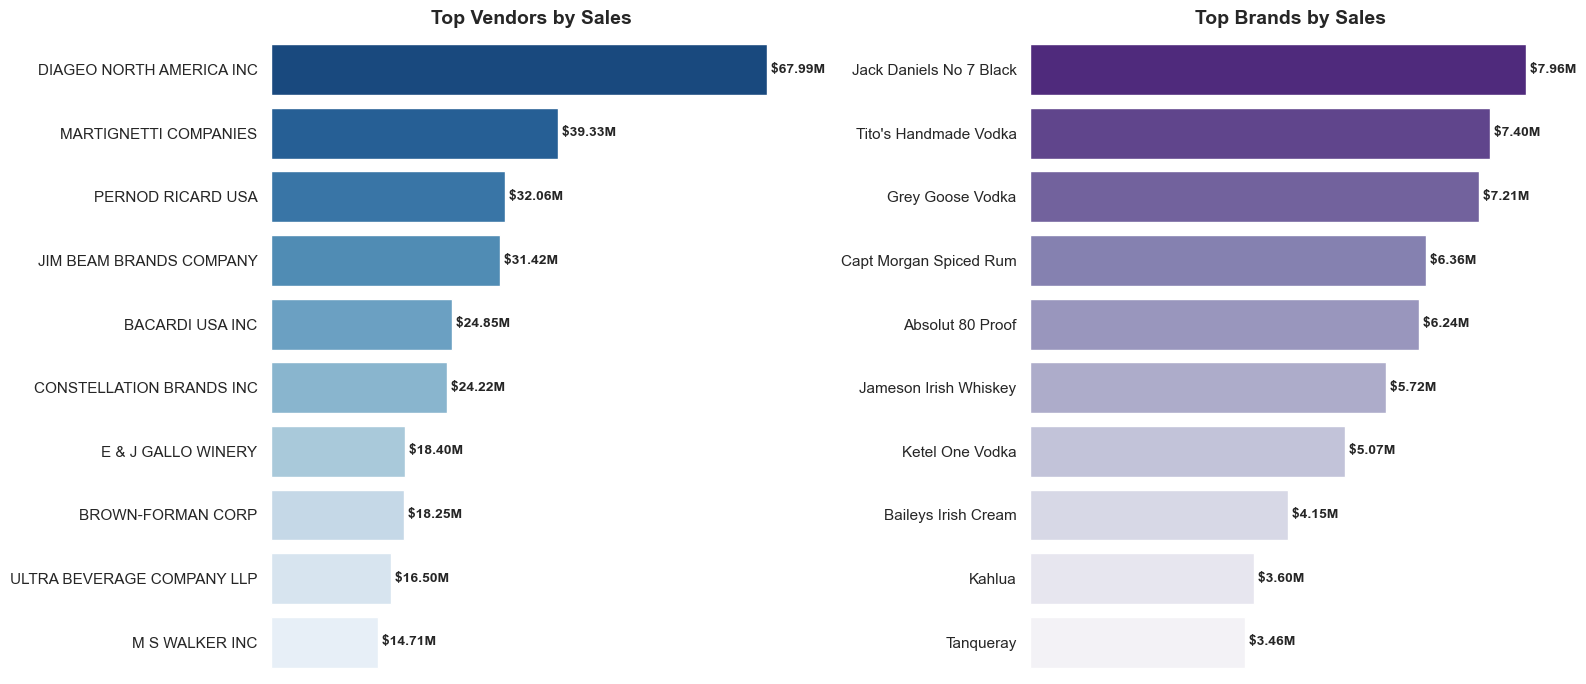

In [173]:
# Convert your variables into clean tables that Python can read without errors
df_vendors = pd.DataFrame(top_vendors)
df_brands = pd.DataFrame(top_brands)

# Create a clean side-by-side screen layout (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
sns.set_theme(style="white")  # Use a clean, plain white background

# ==============================================================================
# STEP 2: BUILD THE LEFT GRAPH (VENDORS)
# ==============================================================================
sns.barplot(
    x='TotalSaleDollar', 
    y='VendorName', 
    data=df_vendors, 
    ax=axes[0],          # Put this on the 1st (left) screen
    palette='Blues_r'    # Beautiful blue color gradient
)
axes[0].set_title('Top Vendors by Sales', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('')   # Hide the bottom labels to keep it clean
axes[0].set_ylabel('')   # Hide the side label since vendor names are clear

# Add the clean currency text (like $1.2M) next to each bar
for index, value in enumerate(df_vendors['TotalSaleDollar']):
    clean_text = format_dollars(value)
    axes[0].text(value, index, f" ${clean_text}", va='center', fontweight='bold', fontsize=10)

# ==============================================================================
# STEP 3: BUILD THE RIGHT GRAPH (BRANDS)
# ==============================================================================
sns.barplot(
    x='TotalSaleDollar', 
    y='Description', 
    data=df_brands, 
    ax=axes[1],          # Put this on the 2nd (right) screen
    palette='Purples_r'  # Beautiful purple color gradient
)
axes[1].set_title('Top Brands by Sales', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('')   # Hide the bottom labels
axes[1].set_ylabel('')   # Hide the side label

# Add the clean currency text (like $450K) next to each bar
for index, value in enumerate(df_brands['TotalSaleDollar']):
    clean_text = format_dollars(value)
    axes[1].text(value, index, f" ${clean_text}", va='center', fontweight='bold', fontsize=10)

# ==============================================================================
# STEP 4: FINAL CLEAN UP AND SHOW
# ==============================================================================
# Remove unnecessary background borders and grid lines
sns.despine(left=True, bottom=True)
axes[0].get_xaxis().set_visible(False) # Hide cluttered numbers on the bottom axis
axes[1].get_xaxis().set_visible(False) # Hide cluttered numbers on the bottom axis

plt.tight_layout()  # Fixes the spacing so no text is cut off
plt.show()          # Show the final beautiful plot!

In [162]:
higher_sales_vendors = df.groupby(['VendorName','Description']).agg({
    'TotalSaleDollar' : 'sum'
}).reset_index()

In [163]:
top_higher_sales_vendors = higher_sales_vendors.sort_values(by='TotalSaleDollar',ascending=False).head(10)

In [164]:
top_higher_sales_vendors['TotalSaleDollar'] = top_higher_sales_vendors['TotalSaleDollar'].apply(format_dollars)

In [165]:
top_higher_sales_vendors

,VendorName,Description,TotalSaleDollar
271,BROWN-FORMAN CORP,Jack Daniels No 7 Black,7.96M
3986,MARTIGNETTI COMPANIES,Tito's Handmade Vodka,7.40M
102,BACARDI USA INC,Grey Goose Vodka,7.21M
1060,DIAGEO NORTH AMERICA INC,Capt Morgan Spiced Rum,6.36M
4969,PERNOD RICARD USA,Absolut 80 Proof,6.24M
5041,PERNOD RICARD USA,Jameson Irish Whiskey,5.72M
1154,DIAGEO NORTH AMERICA INC,Ketel One Vodka,5.07M
1029,DIAGEO NORTH AMERICA INC,Baileys Irish Cream,4.15M
5045,PERNOD RICARD USA,Kahlua,3.60M
1237,DIAGEO NORTH AMERICA INC,Tanqueray,3.46M


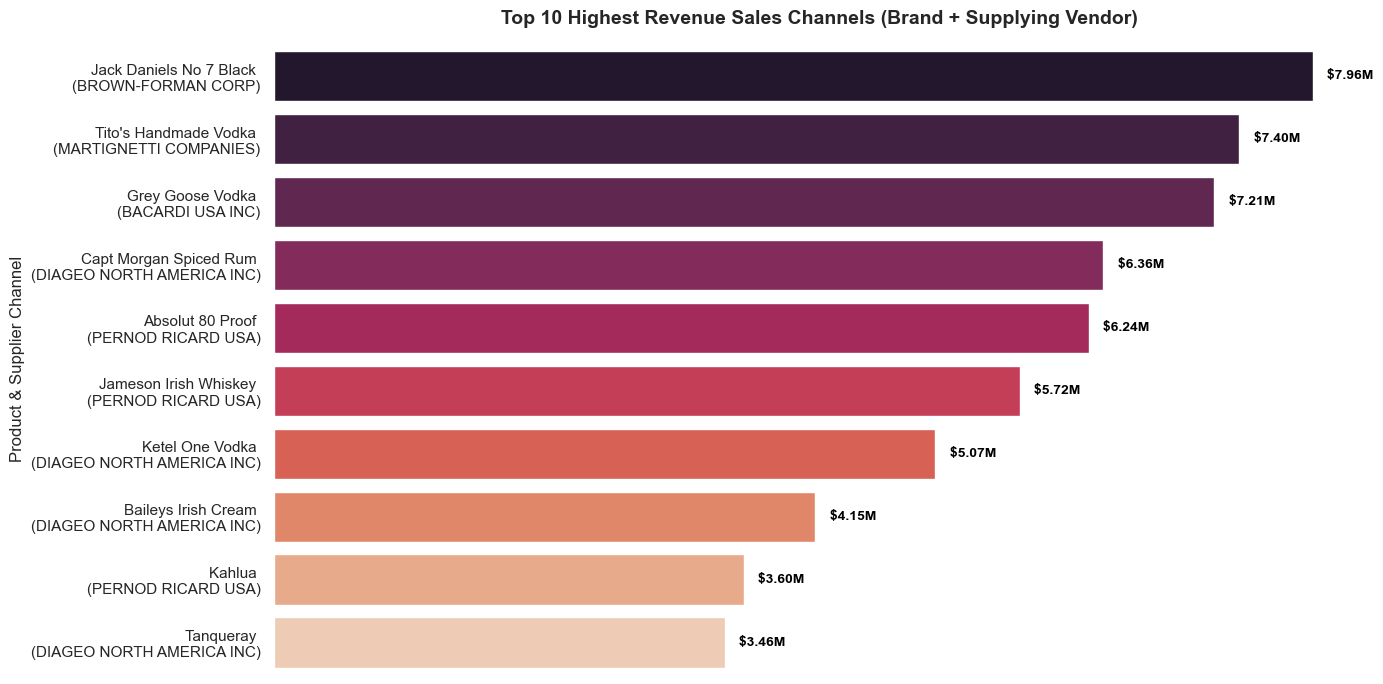

In [169]:
# 1. Get the top 10 rows from your sorted result
top_10_channels = higher_sales_vendors.sort_values(by='TotalSaleDollar', ascending=False).head(10).copy()

# 2. Create a clean, combined label for the Y-axis so you know exactly which product belongs to which vendor
top_10_channels['Channel_Label'] = top_10_channels['Description'] + " \n(" + top_10_channels['VendorName'] + ")"

# 3. Initialize the plot layout
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")  # Adds a faint grid structure for clean scannability

# 4. Draw the horizontal bar chart
ax = sns.barplot(
    data=top_10_channels,
    x='TotalSaleDollar',
    y='Channel_Label',
    palette='rocket'  # A professional dark-to-light gradient palette
)

#Use a direct enumerate loop instead of ax.patches to guarantee perfect alignment
max_val = top_10_channels['TotalSaleDollar'].max()
for index, row in enumerate(top_10_channels.itertuples()):
    value = row.TotalSaleDollar
    formatted_text = format_dollars(value)
    
    # Place text dynamically just past the edge of the bar
    ax.text(
        value + (max_val * 0.01),  # Dynamic padding to stop text jumping around
        index,                     # Clean row indexing alignment 
        f" ${formatted_text}", 
        ha='left', 
        va='center', 
        fontsize=10, 
        color='black',
        fontweight='bold'
    )

# 6. Formatting details to maximize scannability
plt.title('Top 10 Highest Revenue Sales Channels (Brand + Supplying Vendor)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product & Supplier Channel', fontsize=12)

# Hide clutter on the bottom axis line since each bar now has its clean text label
ax.get_xaxis().set_visible(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

##### Which vendor contribute the most to total purchase dollars?

In [204]:
top_vendors_purchase = df.groupby('VendorName').agg({
    'TotalPurchaseDollar':'sum', 
}).reset_index()
vendor_purchase_performance = top_vendors_purchase.sort_values(by='TotalPurchaseDollar',ascending=False).head(10)

In [207]:
vendor_purchase_performance

,VendorName,TotalPurchaseDollar
25,DIAGEO NORTH AMERICA INC,50097226.16
57,MARTIGNETTI COMPANIES,25502095.83
68,PERNOD RICARD USA,23851164.17
46,JIM BEAM BRANDS COMPANY,23494304.32
6,BACARDI USA INC,17432020.26
20,CONSTELLATION BRANDS INC,15273708.08
11,BROWN-FORMAN CORP,13238939.18
30,E & J GALLO WINERY,12068539.22
106,ULTRA BEVERAGE COMPANY LLP,11167081.61
53,M S WALKER INC,9764312.60


In [206]:
fvendor_performance = vendor_purchase_performance.copy()
fvendor_performance['TotalPurchaseDollar'] = fvendor_performance['TotalPurchaseDollar'].apply(format_dollars)
display(fvendor_performance)

,VendorName,TotalPurchaseDollar
25,DIAGEO NORTH AMERICA INC,50.10M
57,MARTIGNETTI COMPANIES,25.50M
68,PERNOD RICARD USA,23.85M
46,JIM BEAM BRANDS COMPANY,23.49M
6,BACARDI USA INC,17.43M
20,CONSTELLATION BRANDS INC,15.27M
11,BROWN-FORMAN CORP,13.24M
30,E & J GALLO WINERY,12.07M
106,ULTRA BEVERAGE COMPANY LLP,11.17M
53,M S WALKER INC,9.76M


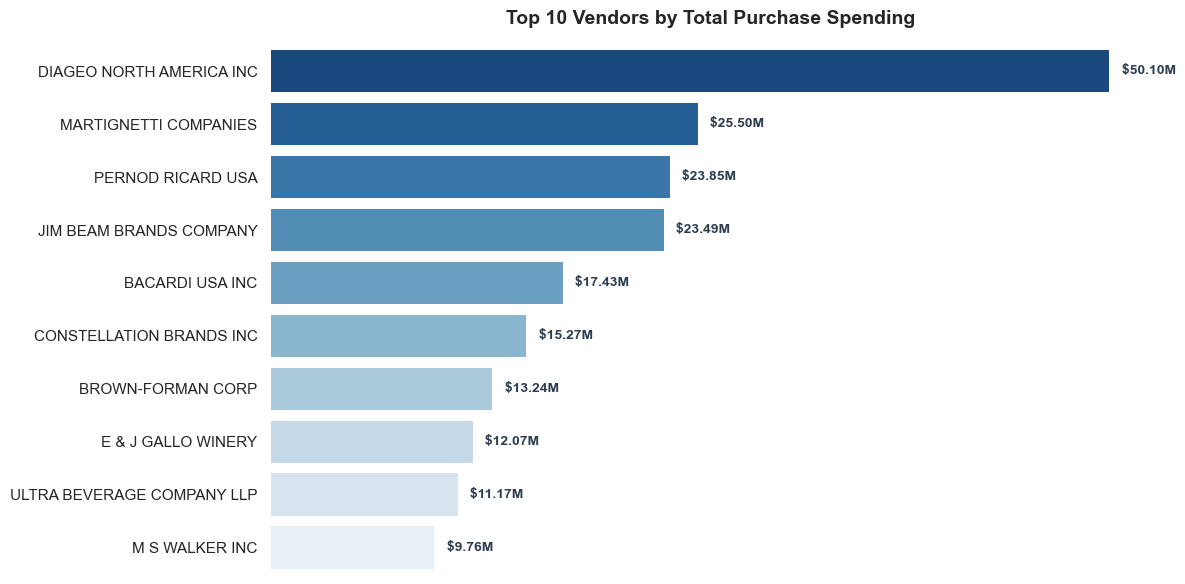

In [208]:
# 1. Set up a clean canvas layout
plt.figure(figsize=(12, 6))
sns.set_theme(style="white")  # Minimal corporate look

# 2. Plot directly from your pre-sorted DataFrame variable
ax = sns.barplot(
    data=vendor_purchase_performance,
    x='TotalPurchaseDollar',
    y='VendorName',
    palette='Blues_r',  # Dark-to-light gradient matches your sorted data
    edgecolor='none'
)

# 3. Add labels at the end of each bar using your 'format_dollars' function
max_val = vendor_purchase_performance['TotalPurchaseDollar'].max()

for index, row in enumerate(vendor_purchase_performance.itertuples()):
    raw_value = row.TotalPurchaseDollar
    clean_label = format_dollars(raw_value)
    
    # Place text dynamically just past the edge of the bar
    ax.text(
        raw_value + (max_val * 0.01),  # Safe spacing padding
        index,
        f" ${clean_label}",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 4. Final title and layout polish
plt.title('Top 10 Vendors by Total Purchase Spending', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('')  
plt.ylabel('')  

# Clean up axes clutter since bars are directly labeled
ax.get_xaxis().set_visible(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [176]:
# lets see the contribution % of the vendors in total purchase

In [209]:
vendor_purchase_performance

,VendorName,TotalPurchaseDollar
25,DIAGEO NORTH AMERICA INC,50097226.16
57,MARTIGNETTI COMPANIES,25502095.83
68,PERNOD RICARD USA,23851164.17
46,JIM BEAM BRANDS COMPANY,23494304.32
6,BACARDI USA INC,17432020.26
20,CONSTELLATION BRANDS INC,15273708.08
11,BROWN-FORMAN CORP,13238939.18
30,E & J GALLO WINERY,12068539.22
106,ULTRA BEVERAGE COMPANY LLP,11167081.61
53,M S WALKER INC,9764312.60


In [210]:
vendor_purchase_performance['PurchaseContribution%'] = (top_vendors_purchase['TotalPurchaseDollar'] / top_vendors_purchase['TotalPurchaseDollar'].sum())*100

In [211]:
vendor_purchase_performance

,VendorName,TotalPurchaseDollar,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,16.300345
57,MARTIGNETTI COMPANIES,25502095.83,8.297724
68,PERNOD RICARD USA,23851164.17,7.760554
46,JIM BEAM BRANDS COMPANY,23494304.32,7.644441
6,BACARDI USA INC,17432020.26,5.671930
20,CONSTELLATION BRANDS INC,15273708.08,4.969671
11,BROWN-FORMAN CORP,13238939.18,4.307609
30,E & J GALLO WINERY,12068539.22,3.926791
106,ULTRA BEVERAGE COMPANY LLP,11167081.61,3.633480
53,M S WALKER INC,9764312.60,3.177055


In [214]:
# we need to roundoff the PurchaseContribution% 

vendor_purchase_performance['PurchaseContribution%'] = round((top_vendors_purchase['TotalPurchaseDollar'] / top_vendors_purchase['TotalPurchaseDollar'].sum())*100,2)
vendor_purchase_performance

,VendorName,TotalPurchaseDollar,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,16.30
57,MARTIGNETTI COMPANIES,25502095.83,8.30
68,PERNOD RICARD USA,23851164.17,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7.64
6,BACARDI USA INC,17432020.26,5.67
20,CONSTELLATION BRANDS INC,15273708.08,4.97
11,BROWN-FORMAN CORP,13238939.18,4.31
30,E & J GALLO WINERY,12068539.22,3.93
106,ULTRA BEVERAGE COMPANY LLP,11167081.61,3.63
53,M S WALKER INC,9764312.60,3.18


In [216]:
vendor_purchase_performance['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [217]:
df['VendorName'].unique().shape

(119,)

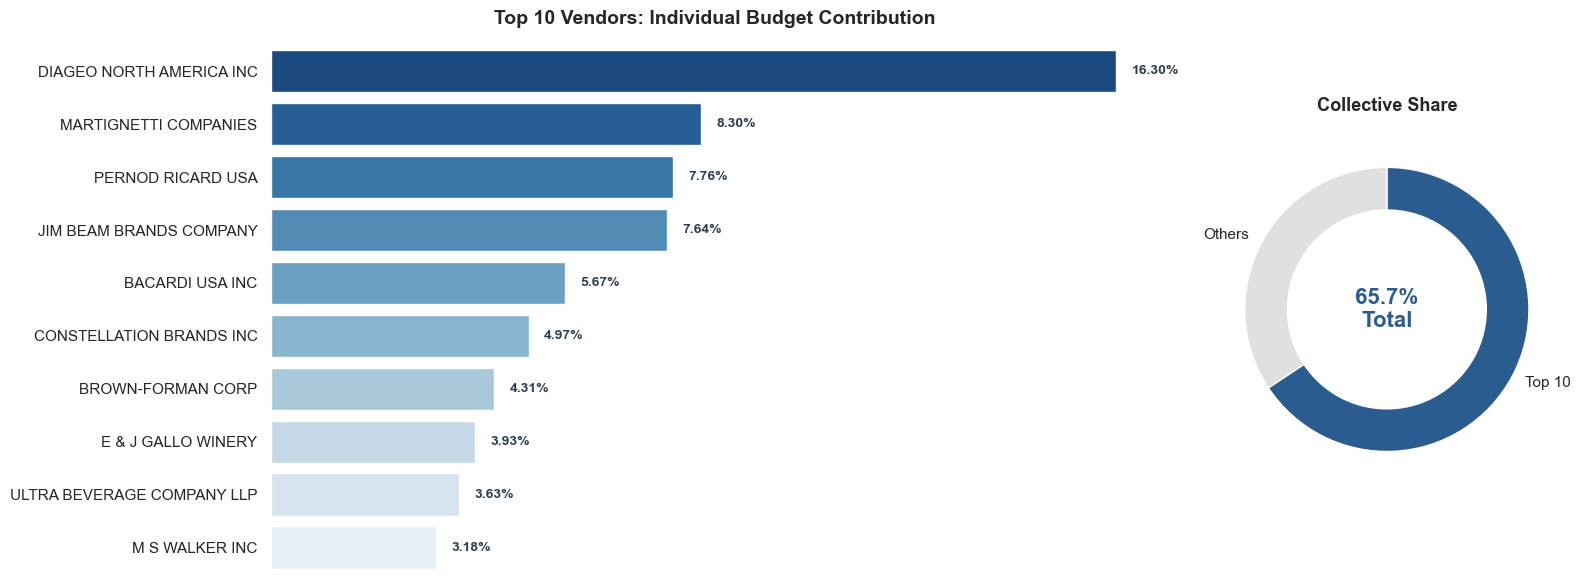

In [220]:
top_venders = vendor_purchase_performance.sort_values(by='PurchaseContribution%', ascending=False).head(10).copy()

# Find the total percentage share of these top 10 players
collective_total = top_venders['PurchaseContribution%'].sum()

# Setup a clean, wide 2-screen canvas (Left screen is wider for the bar chart)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.5, 1]})
sns.set_theme(style="white")  # Clean white backdrop

# ==============================================================================
# STEP 2: LEFT PANEL - INDIVIDUAL VENDOR CONTRIBUTIONS
# ==============================================================================
sns.barplot(
    data=top_venders,
    x='PurchaseContribution%',
    y='VendorName',
    ax=axes[0],       # Place on the left canvas screen
    palette='Blues_r'  # Classic dark-to-light blue gradient
)

axes[0].set_title('Top 10 Vendors: Individual Budget Contribution', fontsize=14, fontweight='bold', pad=15)
axes[0].get_xaxis().set_visible(False)  # Remove cluttered bottom axis numbers
axes[0].set_ylabel('')                  # Remove side label to give names more space

# 🌟 THE EASY FIX: Using .iterrows() handles the '%' column name perfectly without errors
for index, row in enumerate(top_venders.iterrows()):
    # row[1] holds the actual data values for that row
    percentage_val = row[1]['PurchaseContribution%'] 
    
    axes[0].text(
        percentage_val + 0.3,  # Small visual gap past the edge of the bar shape
        index,                 # Aligns vertically row by row
        f"{percentage_val:.2f}%",
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='bold', 
        color='#2c3e50'
    )

# ==============================================================================
# STEP 3: RIGHT PANEL - COLLECTIVE SHARE DONUT CHART
# ==============================================================================
# Draw a clean pie split between the Top 10 and all other suppliers
axes[1].pie(
    [collective_total, 100 - collective_total], 
    labels=['Top 10', 'Others'], 
    colors=['#2b5c8f', '#e0e0e0'], 
    startangle=90, 
    counterclock=False,
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}  # Creates the central donut hole
)

# Insert large, centralized text inside the donut ring
axes[1].text(
    0, 0, 
    f"{collective_total:.1f}%\nTotal", 
    ha='center', 
    va='center', 
    fontsize=16, 
    fontweight='bold', 
    color='#2b5c8f'
)
axes[1].set_title('Collective Share', fontsize=13, fontweight='bold', pad=15)

# Clear boundary boxes to make the dashboard look modern and minimalistic
sns.despine(ax=axes[0], left=True, bottom=True)
sns.despine(ax=axes[1], left=True, bottom=True)

plt.tight_layout()
plt.show()

as we can see the 65.7% or purchases covered by the top 10 vendors which means out of 119 vendors only 10 vendors do the most purchases

##### How much of total procurement is dependent on the top vendors?

In [224]:
vendor_purchase_performance['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [225]:
print(f"Total purchase contribution of top 10 vendors is {vendor_purchase_performance['PurchaseContribution%'].sum()}%")

Total purchase contribution of top 10 vendors is 65.69000000000001%


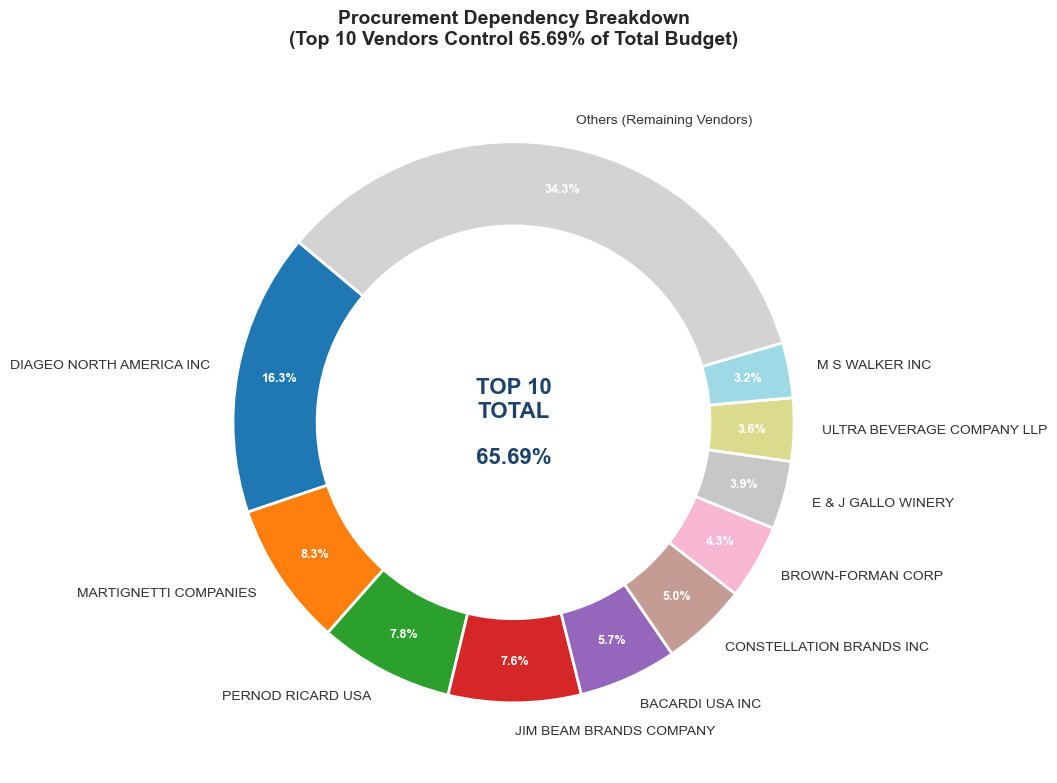

In [226]:

# 1. Top 10 vendors nikalen aur baki bache hue vendors ka total nikalen
top_10 = vendor_purchase_performance.sort_values(by='PurchaseContribution%', ascending=False).head(10).copy()
collective_sum = top_10['PurchaseContribution%'].sum()
others_sum = 100 - collective_sum

# 2. Data ready karein (Top 10 + Others)
labels = top_10['VendorName'].tolist() + ['Others (Remaining Vendors)']
sizes = top_10['PurchaseContribution%'].tolist() + [others_sum]

# 3. Colors set karein (Top 10 ke liye vibrant colors aur Others ke liye light grey)
colors = plt.cm.tab20(np.linspace(0, 1, 10)).tolist() + ['#d3d3d3']

# 4. Plot setup karein
plt.figure(figsize=(10, 8))

# 5. Pie chart draw karein (with autopct to show individual % inside slices)
wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '', # Sirf bade slices par % dikhane ke liye
    startangle=140,
    pctdistance=0.85, # Text ko center se thoda bahar rakhne ke liye
    wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2} # Width 0.3 se donut hole banega
)

# Text and percentage formatting for clarity
plt.setp(texts, fontsize=10, color='#333333')
plt.setp(autotexts, fontsize=9, weight="bold", color="white")

# 6. 🌟 THE SINGLE VISUAL TRICK: Donut ke center hole mein Grand Total likhein
plt.text(
    0, 0, 
    f"TOP 10\nTOTAL\n\n{collective_sum:.2f}%", 
    ha='center', 
    va='center', 
    fontsize=16, 
    fontweight='bold', 
    color='#1c426e'
)

# 7. Title aur Layout
plt.title(f"Procurement Dependency Breakdown\n(Top 10 Vendors Control {collective_sum:.2f}% of Total Budget)", 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

##### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for the cost of savings?


In [227]:
df.head(2)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollar,TotalSalesQuantity,TotalSaleDollar,TotalSalePrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRation
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830


In [228]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollar'] / df['TotalPurchaseQuantity']

In [229]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small','Medium','Large'])

In [230]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


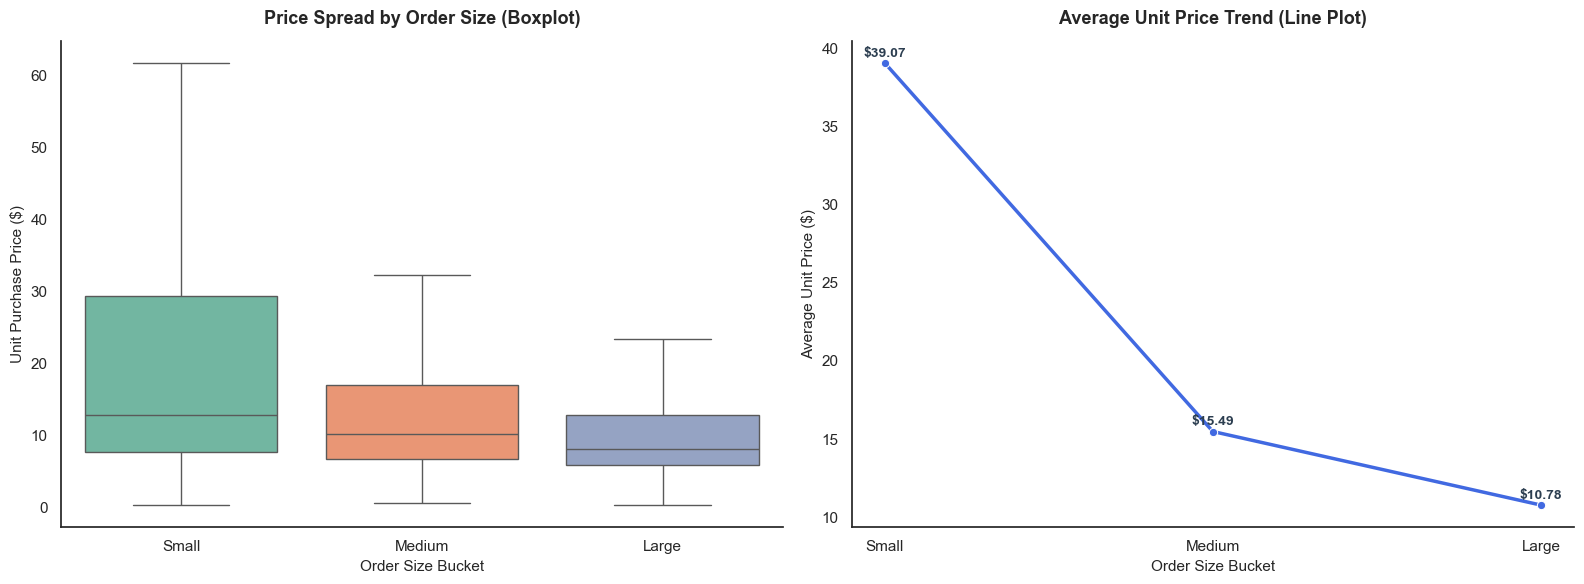

In [262]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean().reset_index()

# 1. Setup a clean 2-panel canvas (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
sns.set_theme(style="whitegrid") # Adds clean grid lines for easy scanning

# Ensure the categories stay in order: Small -> Medium -> Large
order_list = ['Small', 'Medium', 'Large']

# ==============================================================================
# PLOT 1: BOXPLOT (To see price range and outliers)
# ==============================================================================
# This chart shows the spread of prices. If the whole box drops down 
# for 'Large', it proves bulk pricing works across the board.
sns.boxplot(
    data=df,
    x='OrderSize',
    y='UnitPurchasePrice',
    order=order_list,
    ax=axes[0],
    palette='Set2',
    showfliers=False # Hides extreme outliers so the boxes are easy to read
)
axes[0].set_title('Price Spread by Order Size (Boxplot)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Order Size Bucket', fontsize=11)
axes[0].set_ylabel('Unit Purchase Price ($)', fontsize=11)


# ==============================================================================
# PLOT 2: LINE PLOT (To see the exact average trend line)
# ==============================================================================
# This chart calculates the average price for each bucket and draws a line.
# The steepness of the line tells you exactly where the best cost savings are.
brand_summary = df.groupby('OrderSize')[['UnitPurchasePrice']].mean().reindex(order_list).reset_index()

sns.lineplot(
    data=brand_summary,
    x='OrderSize',
    y='UnitPurchasePrice',
    ax=axes[1],
    marker='o',         # Adds a clear dot on each bucket point
    linewidth=2.5,
    color='royalblue'
)
axes[1].set_title('Average Unit Price Trend (Line Plot)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Order Size Bucket', fontsize=11)
axes[1].set_ylabel('Average Unit Price ($)', fontsize=11)

# Add exact price numbers above each dot on the line plot
for index, row in enumerate(brand_summary.itertuples()):
    axes[1].text(
        index, 
        row.UnitPurchasePrice + (brand_summary['UnitPurchasePrice'].max() * 0.01), # Small vertical gap
        f"${row.UnitPurchasePrice:.2f}", 
        ha='center', 
        fontweight='bold', 
        fontsize=10, 
        color='#2c3e50'
    )

# ==============================================================================
# CLEANUP AND DISPLAY
# ==============================================================================
sns.despine() # Remove ugly outer black box frames
plt.tight_layout()
plt.show()

* vendors buying in bulk( large order size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory effieciently.
* the price difference between small and medium order is very high.
* this suggests that bulk pricing strategies successfully encourage vendors to purchase in large volumes, learding to higher overall sales despite lower per unit revenue

##### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [244]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


##### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most of it?

In [246]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'Actualprice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollar',
       'TotalSalesQuantity', 'TotalSaleDollar', 'TotalSalePrice',
       'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin',
       'StockTurnover', 'SalesToPurchaseRation', 'UnitPurchasePrice',
       'OrderSize'],
      dtype='object')

In [249]:
# 1. Calculate the money locked in unsold stock for every single row
# Remaining Units = Purchased - Sold
df['UnsoldQuantity'] = df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']

# Handle edge cases: If sales were higher than purchases (due to delayed data entry), 
# we set unsold quantity to 0 so it doesn't give a negative capital.
df['UnsoldQuantity'] = df['UnsoldQuantity'].clip(lower=0)

# Capital Locked = Unsold Units * What we paid for them (PurchasePrice)
df['CapitalLocked'] = df['UnsoldQuantity'] * df['PurchasePrice']


# 2. Group by Vendor to find the total money stuck per supplier
vendor_inventory_capital = (
    df.groupby(['VendorNumber', 'VendorName'])['CapitalLocked'].sum().reset_index()
    .sort_values(by='CapitalLocked', ascending=False)
)

# 3. Filter for the Top 10 worst offenders for reporting
top_10_locked_capital = vendor_inventory_capital.head(10).copy()

top_10_locked_capital['CapitalLocked_Formatted'] = top_10_locked_capital['CapitalLocked'].apply(format_dollars)

print("--- Top 10 Vendors with Most Capital Locked in Unsold Inventory ---")
display(top_10_locked_capital[['VendorName', 'CapitalLocked_Formatted']])

--- Top 10 Vendors with Most Capital Locked in Unsold Inventory ---


,VendorName,CapitalLocked_Formatted
38,DIAGEO NORTH AMERICA INC,1.40M
40,MARTIGNETTI COMPANIES,882.51K
90,JIM BEAM BRANDS COMPANY,833.26K
94,PERNOD RICARD USA,638.98K
75,ULTRA BEVERAGE COMPANY LLP,506.53K
34,WILLIAM GRANT & SONS INC,468.09K
33,E & J GALLO WINERY,399.97K
14,CONSTELLATION BRANDS INC,346.40K
87,PERFECTA WINES,344.63K
10,BROWN-FORMAN CORP,337.28K


In [255]:
total_capital_locked = df['CapitalLocked'].sum()
print(f"The Total Capital Locked is: {format_dollars(total_capital_locked)}")

The Total Capital Locked is: 9.55M


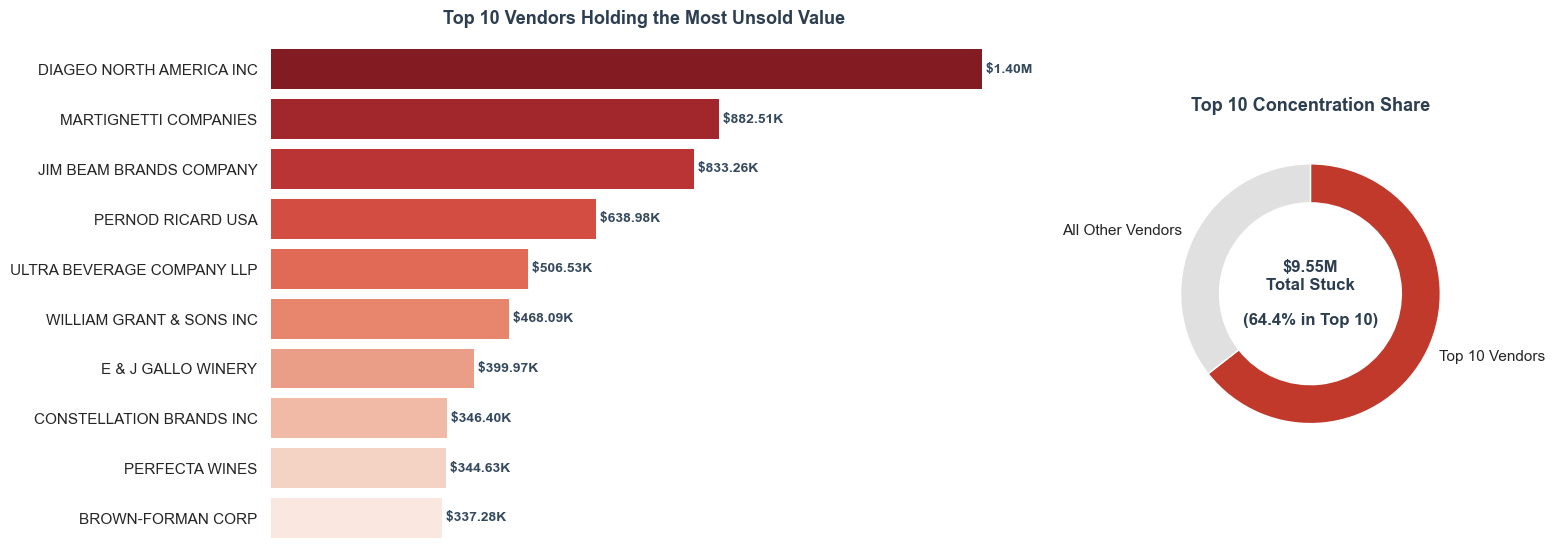

In [257]:
# ==============================================================================
# STEP 1: CALCULATE THE FINANCIAL TOTALS AND SHARES
# ==============================================================================
# 1. Total business-wide locked capital
total_capital_locked = df['CapitalLocked'].sum()
formatted_total = format_dollars(total_capital_locked)

# 2. Total locked capital just from our Top 10 players
top_10_total = top_10_locked_capital['CapitalLocked'].sum()

# 3. Calculate the percentage share held by the Top 10
top_10_share_percent = (top_10_total / total_capital_locked) * 100
rest_of_business_share = 100 - top_10_share_percent

# ==============================================================================
# STEP 2: INITIALIZE THE 2-PANEL DASHBOARD LAYOUT
# ==============================================================================
# Left chart gets 70% of the screen space, right donut chart gets 30%
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.3, 1]})
sns.set_theme(style="white")

# ==============================================================================
# PANEL 1: INDIVIDUAL VENDOR VALUES (LEFT SCREEN)
# ==============================================================================
ax = sns.barplot(
    data=top_10_locked_capital,
    x='CapitalLocked',
    y='VendorName',
    ax=axes[0],
    palette='Reds_r',  # Risk crimson theme
    edgecolor='none'
)
axes[0].set_title('Top 10 Vendors Holding the Most Unsold Value', fontsize=13, fontweight='bold', pad=15, color='#2c3e50')
axes[0].get_xaxis().set_visible(False)  # Remove cluttered bottom axis numbers
axes[0].set_ylabel('')                  # Hide side label to give names space

# Attach individual price tags to the tips of the bars
for index, row in enumerate(top_10_locked_capital.itertuples()):
    clean_text = str(row.CapitalLocked_Formatted)
    raw_value = row.CapitalLocked
    axes[0].text(
        raw_value, index, f" ${clean_text}",
        va='center', ha='left', fontsize=10, fontweight='bold', color='#34495e'
    )

# ==============================================================================
# PANEL 2: COLLECTIVE SHARE DONUT CHART (RIGHT SCREEN)
# ==============================================================================
# Draw a clean pie split showing how much of the pie the Top 10 occupies
axes[1].pie(
    [top_10_share_percent, rest_of_business_share], 
    labels=['Top 10 Vendors', 'All Other Vendors'], 
    colors=['#c0392b', '#e0e0e0'], # Crimson for risk, light grey for baseline
    startangle=90, 
    counterclock=False,
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}  # Creates the central donut hole
)

# Insert a giant formatted overall total dollar score inside the donut hole
axes[1].text(
    0, 0, 
    f"${formatted_total}\nTotal Stuck\n\n({top_10_share_percent:.1f}% in Top 10)", 
    ha='center', va='center', 
    fontsize=12, fontweight='bold', color='#2c3e50'
)
axes[1].set_title('Top 10 Concentration Share', fontsize=13, fontweight='bold', pad=15, color='#2c3e50')

# ==============================================================================
# FINAL DESIGN POLISH
# ==============================================================================
sns.despine(ax=axes[0], left=True, bottom=True)  # Wipe away left panel borders
plt.tight_layout(pad=2.0)
plt.show()

##### What is the 95% of confidence intervals for profit margins of top performing and low performing vendors 

In [258]:
top_threshold = df['TotalSaleDollar'].quantile(0.75)
low_threshold = df['TotalSaleDollar'].quantile(0.25)

In [259]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Clean data: Filter out highly distorted negative profit margins
clean_df = df[df['ProfitMargin'] >= 0].copy()

# 2. Segment vendors by revenue performance
# Aggregate sales and average margin at the vendor level
vendor_perf = clean_df.groupby('VendorName').agg({
    'TotalSaleDollar': 'sum',
    'ProfitMargin': 'mean'
}).reset_index()

# Define thresholds (e.g., Top 20% and Bottom 20% by total sales)
top_threshold = vendor_perf['TotalSaleDollar'].quantile(0.75)
low_threshold = vendor_perf['TotalSaleDollar'].quantile(0.25)

top_vendors_margins = vendor_perf[vendor_perf['TotalSaleDollar'] >= top_threshold]['ProfitMargin']
low_vendors_margins = vendor_perf[vendor_perf['TotalSaleDollar'] <= low_threshold]['ProfitMargin']

# 3. Function to calculate 95% Confidence Interval
def calculate_95_ci(data, label):
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)  # Standard Error of the Mean
    
    # Calculate 95% CI using t-distribution (safer for smaller sample subsets)
    ci_lower, ci_upper = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=sem)
    
    print(f"=== 95% Confidence Interval for {label} Vendors ===")
    print(f"Sample Size (n): {n}")
    print(f"Sample Mean Margin: {mean:.2f}%")
    print(f"95% Confidence Interval: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
    print(f"Margin of Error: ±{(ci_upper - mean):.2f}%\n")
    return ci_lower, ci_upper

# 4. Execute calculations
top_ci = calculate_95_ci(top_vendors_margins, "Top Performing (High Revenue)")
low_ci = calculate_95_ci(low_vendors_margins, "Low Performing (Low Revenue)")


=== 95% Confidence Interval for Top Performing (High Revenue) Vendors ===
Sample Size (n): 30
Sample Mean Margin: 36.73%
95% Confidence Interval: [34.78%, 38.68%]
Margin of Error: ±1.95%

=== 95% Confidence Interval for Low Performing (Low Revenue) Vendors ===
Sample Size (n): 30
Sample Mean Margin: 39.49%
95% Confidence Interval: [31.13%, 47.86%]
Margin of Error: ±8.37%



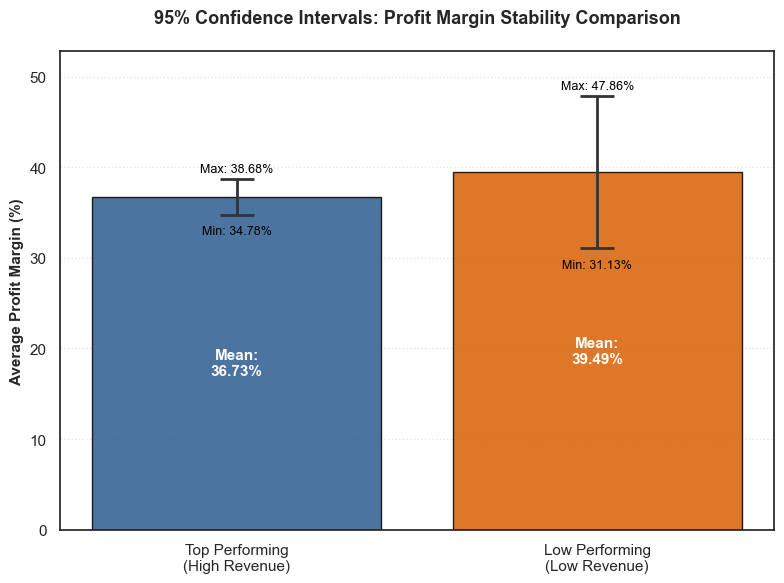

In [261]:
# 1. Prepare data for plotting
categories = ['Top Performing\n(High Revenue)', 'Low Performing\n(Low Revenue)']
means = [top_vendors_margins.mean(), low_vendors_margins.mean()]

# Calculate the error distance from the mean for the error bars
# Error = Upper Boundary - Mean
top_error = top_ci[1] - means[0]
low_error = low_ci[1] - means[1]
errors = [top_error, low_error]

# 2. Initialize the plot layout
plt.figure(figsize=(8, 6))

# 3. Create a bar chart with explicit error bars (yerr)
# capsize=10 adds the neat horizontal caps at the top and bottom of the interval lines
bars = plt.bar(
    categories, 
    means, 
    yerr=errors, 
    capsize=12, 
    color=['#2b5c8f', '#d95f02'], 
    edgecolor='black',
    alpha=0.85,
    error_kw={'lw': 2, 'capthick': 2, 'ecolor': '#333333'}
)

# 4. Add exact value tags inside/above the bars for instant clarity
for i, bar in enumerate(bars):
    # Mean value label
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        means[i] / 2, 
        f"Mean:\n{means[i]:.2f}%", 
        ha='center', va='center', color='white', fontweight='bold', fontsize=11
    )
    
    # Upper and Lower bound markers (text annotations)
    lower_val = means[i] - errors[i]
    upper_val = means[i] + errors[i]
    
    plt.text(bar.get_x() + bar.get_width()/2, upper_val + 0.5, f"Max: {upper_val:.2f}%", ha='center', va='bottom', color='black', fontsize=9)
    plt.text(bar.get_x() + bar.get_width()/2, lower_val - 1.2, f"Min: {lower_val:.2f}%", ha='center', va='top', color='black', fontsize=9)

# 5. Styling and labels
plt.title('95% Confidence Intervals: Profit Margin Stability Comparison', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Average Profit Margin (%)', fontsize=11, fontweight='bold')
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

# Dynamic Y-axis spacing to avoid clipping tags
plt.ylim(0, max(means[0] + top_error, means[1] + low_error) + 5)

plt.tight_layout()
plt.show()
